### Загрузка данных

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [90]:
TRAIN = "https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/chocolate_train.csv"
TEST = "https://raw.githubusercontent.com/evgpat/edu_stepik_practical_ml/main/datasets/chocolate_test_new.csv"
RANDOM_STATE = 42

`Company` - компания производитель  
`Specific Bean Origin` - географический регион происхождения  
`REF` - параметр, определяющий момент внесения записи в базу данных (чем выше значение, тем "свежее" запись)  
`Review` - дата публикации отзыва  
`Cocoa Percent` - процентное содержание какао  
`Company Location` - страна производитель  
`Rating` - экспертный рейтинг  
`Bean Type` - используемый сорт какао-бобов, если таковой имеется  
`Broad Bean Origin` - географический регион происхождения какао-бобов

### EDA - разведочный анализ данных

In [91]:
df = pd.read_csv(TRAIN)
df[:5]

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,457,2009,72%,U.K.,3.25,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",508,2010,72%,Switzerland,3.50,,Venezuela
2,Dark Forest,Tanzania,1554,2015,70%,U.S.A.,3.00,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,1125,2013,72%,U.S.A.,3.00,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",32,2006,75%,France,3.50,Criollo,Indonesia


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1255 non-null   object 
 1   Specific Bean Origin  1255 non-null   object 
 2   REF                   1255 non-null   int64  
 3   Review                1255 non-null   int64  
 4   Cocoa Percent         1255 non-null   object 
 5   Company Location      1255 non-null   object 
 6   Rating                1255 non-null   float64
 7   Bean Type             1254 non-null   object 
 8   Broad Bean Origin     1254 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 88.4+ KB


В датасете есть всего два пропущенных значения. Удалим их с помощью dropna

In [93]:
df = df.dropna()

In [94]:
print(df.shape)
df[:5]

(1253, 9)


,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,457,2009,72%,U.K.,3.25,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",508,2010,72%,Switzerland,3.50,,Venezuela
2,Dark Forest,Tanzania,1554,2015,70%,U.S.A.,3.00,,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,1125,2013,72%,U.S.A.,3.00,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",32,2006,75%,France,3.50,Criollo,Indonesia


В колонке Bean Type остались пустые значения, хотя мы применили dropna. Скорее всего, это пробел. Посмотрим, сколько всего таких пропусков во всем датасете. Для этого заменим пробелы на NaN.  
Пояснение про r'^\s*$':  

`r` - форматирование строки  
`^` - с начала строки  
`\s`- поиск символа пробела  
`*` - количество пробелов. * означает любое количество 0  
`$` - до конца строки  
`regex = True` означает использование регулярного выражения, а не точного совпадения строки

In [95]:
df = df.replace(r'^\s*$', np.nan, regex=True)
df.isnull().sum()

Company                   0
Specific Bean Origin      0
REF                       0
Review                    0
Cocoa Percent             0
Company Location          0
Rating                    0
Bean Type               628
Broad Bean Origin        55
dtype: int64

Мы видим, что у нас есть 683 пропуска в датасете. Это больше половины. Просто удалить их, как сделали выше, нельзя. Проблема в том, что эти колонки - текстовые, то есть медианой их заменить нельзя. Заменим их на значение 'Unknown'. Если у таких данных найдется закономерность, модель это увидит

In [96]:
df[['Bean Type', 'Broad Bean Origin']] = df[['Bean Type', 'Broad Bean Origin']].fillna('Unknown')
df[:5]

,Company,Specific Bean Origin,REF,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin
0,Willie's Cacao,Rio Caribe,457,2009,72%,U.K.,3.25,Trinitario,Venezuela
1,Beschle (Felchlin),"Ocumare, Premier Cru, Quizas No. 2",508,2010,72%,Switzerland,3.50,Unknown,Venezuela
2,Dark Forest,Tanzania,1554,2015,70%,U.S.A.,3.00,Unknown,Tanzania
3,Brasstown aka It's Chocolate,Cooproagro,1125,2013,72%,U.S.A.,3.00,Trinitario,Dominican Republic
4,Pralus,"Java, Indonesie",32,2006,75%,France,3.50,Criollo,Indonesia


Теперь надо убрать проценты из признака Cocoa Percent, чтобы этот столбец имел тип данных int

In [97]:
df['Cocoa Percent'] = df['Cocoa Percent'].str.replace('%', '').astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1253 entries, 0 to 1254
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1253 non-null   object 
 1   Specific Bean Origin  1253 non-null   object 
 2   REF                   1253 non-null   int64  
 3   Review                1253 non-null   int64  
 4   Cocoa Percent         1253 non-null   float64
 5   Company Location      1253 non-null   object 
 6   Rating                1253 non-null   float64
 7   Bean Type             1253 non-null   object 
 8   Broad Bean Origin     1253 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 97.9+ KB


Посмотрим на количество уникальных значений в каждой колонке

In [98]:
for i in df.columns:
    print(i, len(df[i].unique()))

Company 376
Specific Bean Origin 761
REF 433
Review 12
Cocoa Percent 40
Company Location 58
Rating 13
Bean Type 38
Broad Bean Origin 83


Посмотрим на матрицу корреляций между числовыми и вещественными колонками

<Axes: >

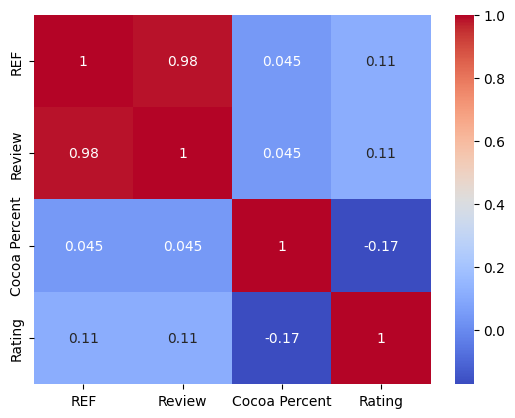

In [99]:
import seaborn as sns

corr_cols = df.columns[df.dtypes != 'object']
corr = df[corr_cols].corr()
sns.heatmap(corr, cmap='coolwarm', annot=True)

<Axes: >

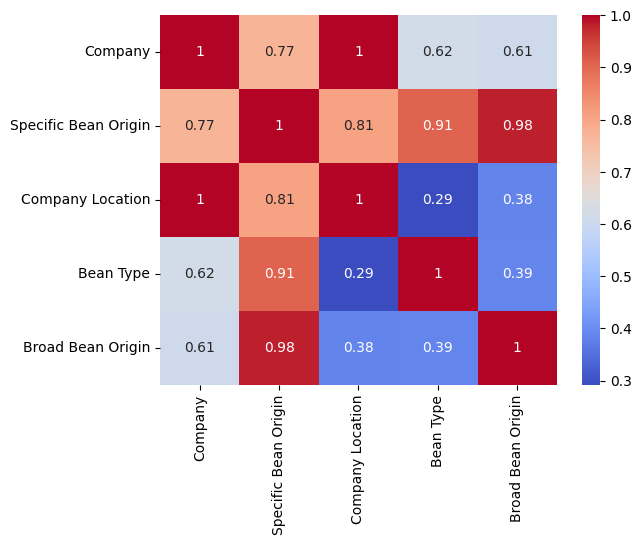

In [100]:
import association_metrics as am

corr_cols = df.apply(lambda x: x.astype('category') if x.dtype == 'object' else x)
cramer = am.CramersV(corr_cols)
matrix = cramer.fit()
sns.heatmap(matrix, cmap='coolwarm', annot=True)

### Feature Engineering

Что мы видим: Review очень сильно коррелирует с REF. Значит, один из столбцов надо удалить. В Review 12 уникальных значений, в REF 433. Какой лучше убрать? Я думаю REF, потому что его можно спутать с id продукта. 

Specific Bean Origin(761 значение) тоже сильно коррелирует с Broad Bean Origin(83 значения) и Bean Type(38). И чуть менее слабо с Company Location(58). Что с ним делать? Хотя это очень важный признак, мне кажется, что его стоит удалить, потому что это более подробный столбец Broad Bean Origin.

Итог: BEF и Specific Bean Origin удалить

In [101]:
df = df.drop(['REF', 'Specific Bean Origin'], axis=1)

In [102]:
# Является ли шоколад смесью сортов или привезен из нескольких стран
df['is_blend_type'] = df['Bean Type'].apply(lambda x: 1 if ',' in str(x) or 'blend' in str(x).lower() else 0)
df['is_blend_origin'] = df['Broad Bean Origin'].apply(lambda x: 1 if ',' in str(x) or 'blend' in str(x).lower() else 0)

# Указан ли конкретный сорт бобов
df['is_known_bean'] = df['Bean Type'].apply(lambda x: 0 if x == 'Unknown' else 1)

In [103]:
df

,Company,Review,Cocoa Percent,Company Location,Rating,Bean Type,Broad Bean Origin,is_blend_type,is_blend_origin,is_known_bean
0,Willie's Cacao,2009,72.0,U.K.,3.25,Trinitario,Venezuela,0,0,1
1,Beschle (Felchlin),2010,72.0,Switzerland,3.50,Unknown,Venezuela,0,0,0
2,Dark Forest,2015,70.0,U.S.A.,3.00,Unknown,Tanzania,0,0,0
3,Brasstown aka It's Chocolate,2013,72.0,U.S.A.,3.00,Trinitario,Dominican Republic,0,0,1
4,Pralus,2006,75.0,France,3.50,Criollo,Indonesia,0,0,1
...,...,...,...,...,...,...,...,...,...,...
1250,Artisan du Chocolat,2009,80.0,U.K.,3.00,"Criollo, Trinitario",Madagascar,1,0,1
1251,Marana,2016,70.0,Peru,2.75,Unknown,Peru,0,0,0
1252,Arete,2015,68.0,U.S.A.,3.50,Forastero (Nacional),Peru,0,0,1
1253,Fresco,2011,72.0,U.S.A.,3.50,Unknown,Dominican Republic,0,0,0


Теперь можно разделять данные на тренировочные и тестовые

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

x = df.drop('Rating', axis=1)
y = df['Rating']

In [105]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.25, random_state=RANDOM_STATE)

In [106]:
cat_cols = x.columns[x.dtypes == 'object']
num_cols = x.columns[x.dtypes != 'object']

Review


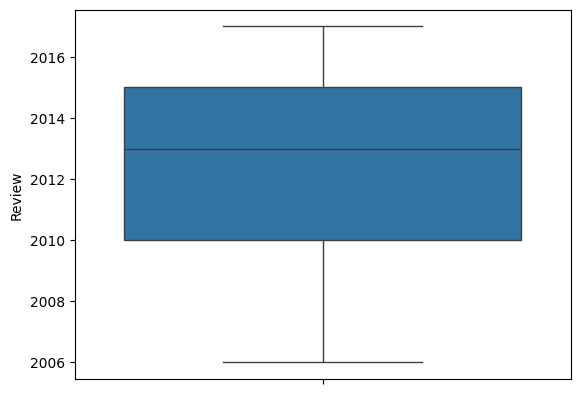

Cocoa Percent


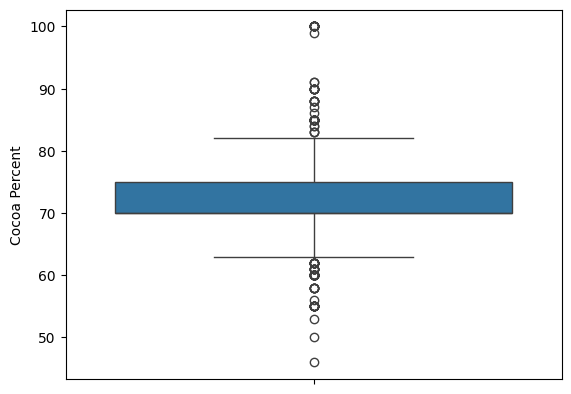

is_blend_type


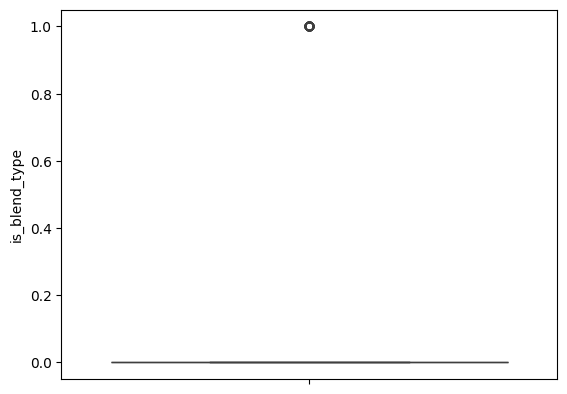

is_blend_origin


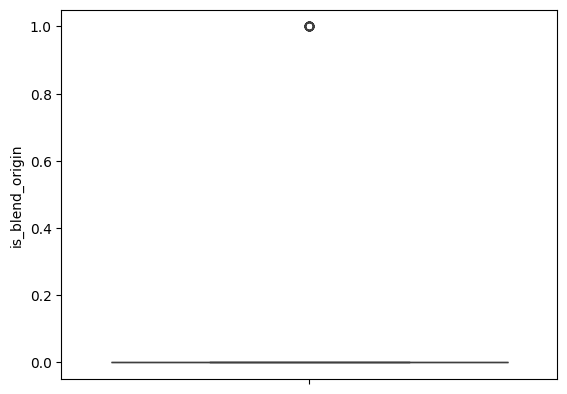

is_known_bean


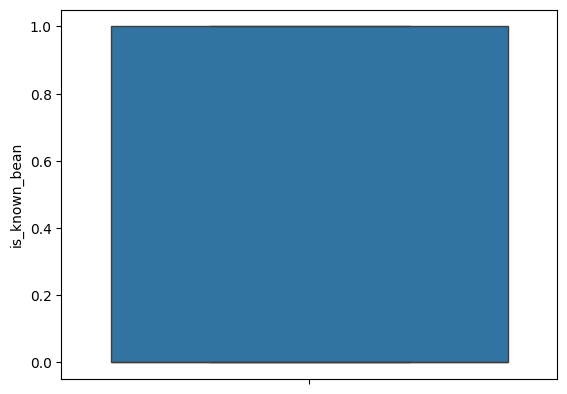

In [107]:
for i in num_cols:
    print(i)
    sns.boxplot(x[i])
    plt.show()

Я не понял, почему тут выбросы, так что не знаю, какие выводы делать. Поэтому ничего менять не буду

### Создание и обучение модели

Создадим biseline модели. Будем использовать случайный лес и регрессию.

План такой: 
- Кодировщик
- Склейлер
- Модель 


In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.model_selection import GridSearchCV

In [109]:
p1 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
])

p1.fit(xtrain, ytrain)
pred = p1.predict(xtest)
r2_score(ytest, pred)

-0.04685300608544618

In [110]:
p2 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols, smoothing=1)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
])

p3 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols, smoothing=10)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
])

p4 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols, smoothing=50)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
])

p5 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols, smoothing=100)),
    ('scaler_', StandardScaler()),
    ('model_', LinearRegression())
])

p6 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols)),
    ('scaler_', MinMaxScaler()),
    ('model_', LinearRegression())
])

p7 = Pipeline([
    ('encoder',TargetEncoder(cols=cat_cols, smoothing=1)),
    ('scaler_', MinMaxScaler()),
    ('model_', LinearRegression())
])

p8 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols, smoothing=10)),
    ('scaler_', MinMaxScaler()),
    ('model_', LinearRegression())
])

p9 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols, smoothing=50)),
    ('scaler_', MinMaxScaler()),
    ('model_', LinearRegression())
])

p10 = Pipeline([
    ('encoder_',TargetEncoder(cols=cat_cols, smoothing=100)),
    ('scaler_', MinMaxScaler()),
    ('model_', LinearRegression())
])

In [111]:
for i,p in enumerate([p1,p2,p3,p4,p5,p6,p7,p8,p9,p10]):
    p.fit(xtrain, ytrain)
    pred = p.predict(xtest)
    print(i+1, r2_score(ytest, pred))

1 -0.04685300608544618
2 0.014960348337193174
3 -0.04685300608544618
4 -0.14672886207377878
5 -0.15425837766397543
6 -0.0468530060854464
7 0.01496034833719384
8 -0.0468530060854464
9 -0.14672886207377855
10 -0.15425837766397632


У линейной регрессии лучшая модель получилась с результатом
0.0019185042138686326 и параметрами: smoothing=1, MinMaxScaler. 
Это значит, модель почти не видит связи между данными

Применим GridSearchCV для поиска более подходящих параметров

In [112]:
params = {
    'encoder__smoothing': [1,10,50,100],
    'scaler_': [MinMaxScaler(), StandardScaler()]
}

logreg_gs = GridSearchCV(p7, param_grid=params, cv=5, scoring='r2', n_jobs=-1)
logreg_gs.fit(xtrain, ytrain)

print(logreg_gs.best_score_)
print(logreg_gs.best_params_)

0.07951641322689143
{'encoder__smoothing': 10, 'scaler_': StandardScaler()}


In [113]:
best_lr = logreg_gs.best_estimator_

In [126]:
pred_lr = best_lr.predict(xtest)
r2_score(ytest, pred_lr)

-0.04685300608544618

Перейдем к случайному лесу

In [ ]:
p11 = Pipeline([
    ('encoder', TargetEncoder(cols=cat_cols)),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE))
])

In [115]:
params = {
    'model__n_estimators': np.arange(25,200,25),
    'model__max_depth': np.arange(0,10,1),
    'model__min_samples_leaf':[1,2,3,4],
    'model__max_features':['sqrt','log2']
}

ranfor_gs = GridSearchCV(p11, param_grid=params, cv=5, scoring='r2', n_jobs=-1, verbose=2)
ranfor_gs.fit(xtrain, ytrain)

best_rf = ranfor_gs.best_estimator_
print(ranfor_gs.best_score_)
print(ranfor_gs.best_params_)

Fitting 5 folds for each of 560 candidates, totalling 2800 fits
0.15036604266406034
{'model__max_depth': np.int64(4), 'model__max_features': 'sqrt', 'model__min_samples_leaf': 4, 'model__n_estimators': np.int64(25)}


In [124]:
pred = best_rf.predict(xtest)
r2_score(ytest, pred)

0.10286832120047995

Результат существенно увеличился. Улучшим модель с помощью Сatboost

In [116]:
from catboost import CatBoostRegressor
p12 = Pipeline([
    ('encoder', TargetEncoder(cols=cat_cols)),
    ('model', CatBoostRegressor(random_state=RANDOM_STATE))
])

params = {
    'encoder__smoothing': [10, 20],
    'model__iterations': [200, 300],
    'model__learning_rate':[0.01, 0.05, 0.1],
    'model__depth':np.arange(6,15),
}

catbst_gs = GridSearchCV(p12, param_grid=params, cv=5, scoring='r2', n_jobs=-1, verbose=False)
catbst_gs.fit(xtrain, ytrain)

best_cb = catbst_gs.best_estimator_
print(catbst_gs.best_score_)
print(catbst_gs.best_params_)

0:	learn: 0.4721419	total: 50.6ms	remaining: 10.1s
1:	learn: 0.4703209	total: 99.4ms	remaining: 9.84s
2:	learn: 0.4684873	total: 146ms	remaining: 9.59s
3:	learn: 0.4665587	total: 148ms	remaining: 7.24s
4:	learn: 0.4647723	total: 174ms	remaining: 6.78s
5:	learn: 0.4630901	total: 223ms	remaining: 7.22s
6:	learn: 0.4614359	total: 273ms	remaining: 7.51s
7:	learn: 0.4596994	total: 299ms	remaining: 7.16s
8:	learn: 0.4579909	total: 300ms	remaining: 6.38s
9:	learn: 0.4562588	total: 349ms	remaining: 6.63s
10:	learn: 0.4546375	total: 397ms	remaining: 6.82s
11:	learn: 0.4530630	total: 443ms	remaining: 6.94s
12:	learn: 0.4515993	total: 489ms	remaining: 7.03s
13:	learn: 0.4501183	total: 537ms	remaining: 7.13s
14:	learn: 0.4485999	total: 585ms	remaining: 7.22s
15:	learn: 0.4469521	total: 636ms	remaining: 7.32s
16:	learn: 0.4453276	total: 683ms	remaining: 7.36s
17:	learn: 0.4437422	total: 730ms	remaining: 7.38s
18:	learn: 0.4422491	total: 737ms	remaining: 7.02s
19:	learn: 0.4406202	total: 783ms	remai

In [127]:
pred_cb = best_cb.predict(xtest)
r2_score(ytest, pred_cb)

0.10832572758153491

Catboost результат не улучшил. Пока самая лучшая моедль это Случайный лес. Попробуем SVM

In [117]:
from sklearn.svm import SVR

p13 = Pipeline([
    ('encoder', TargetEncoder(cols=cat_cols)),
    ('scaler', StandardScaler()),
    ('model', SVR())    
])

params = {
    'model__C': np.arange(1,2,0.1),
    'model__kernel':['rbf','poly','sigmoid','linear'],
    'model__epsilon':np.arange(0.5,1,0.1)
}

svr_gs = GridSearchCV(p13, param_grid=params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
svr_gs.fit(xtrain,ytrain)

best_svr = svr_gs.best_estimator_
print(svr_gs.best_score_)
print(svr_gs.best_params_)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
0.12218601164916468
{'model__C': np.float64(1.2000000000000002), 'model__epsilon': np.float64(0.6), 'model__kernel': 'linear'}


In [128]:
pred_svr = best_svr.predict(xtest)
r2_score(ytest, pred_svr)

0.02869335623013869

SVR тоже не справился

In [118]:
import optuna
from sklearn.model_selection import cross_val_score

def objective_dt(trial):
    params = {
        'encoder__smoothing': trial.suggest_float('smoothing', 1.0, 100.0),
        'model__n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'model__max_depth': trial.suggest_int('max_depth', 2, 20),
        'model__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
    }

    pipeline = Pipeline([
        ('encoder', TargetEncoder(cols=cat_cols)),
        ('scaler', StandardScaler()),
        ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ])
    
    pipeline.set_params(**params)
    
    score = cross_val_score(pipeline, xtrain, ytrain, cv=5, scoring='r2').mean()
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective_dt, n_trials=300)

print("Лучший R2:", study.best_value)
print("Лучшие параметры:", study.best_params)

[I 2026-04-16 19:30:53,433] A new study created in memory with name: no-name-ebf301e6-7047-437f-b887-f26db6053744
[I 2026-04-16 19:30:54,851] Trial 0 finished with value: 0.01876599737490927 and parameters: {'smoothing': 75.1756265852003, 'n_estimators': 235, 'max_depth': 10, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.01876599737490927.
[I 2026-04-16 19:30:55,500] Trial 1 finished with value: 0.04477332532739538 and parameters: {'smoothing': 38.99462841239787, 'n_estimators': 86, 'max_depth': 8, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.04477332532739538.
[I 2026-04-16 19:30:56,027] Trial 2 finished with value: 0.02311433811047303 and parameters: {'smoothing': 33.15523205789203, 'n_estimators': 57, 'max_depth': 16, 'min_samples_leaf': 7}. Best is trial 1 with value: 0.04477332532739538.
[I 2026-04-16 19:30:56,767] Trial 3 finished with value: 0.016827573028535502 and parameters: {'smoothing': 50.47921233977848, 'n_estimators': 97, 'max_depth': 7, 'min_samples_lea

Лучший R2: 0.1961438789939351
Лучшие параметры: {'smoothing': 1.0455570745869749, 'n_estimators': 173, 'max_depth': 9, 'min_samples_leaf': 1}


In [ ]:
best_params_rf = study.best_params

final_pipeline = Pipeline([
    ('encoder', TargetEncoder(cols=cat_cols)),
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

final_pipeline.set_params(
    encoder__smoothing=best_params_rf['smoothing'],
    model__n_estimators=best_params_rf['n_estimators'],
    model__max_depth=best_params_rf['max_depth'],
    model__min_samples_leaf=best_params_rf['min_samples_leaf']
)

final_pipeline.fit(xtrain, ytrain)
final_pred = final_pipeline.predict(xtest)

r2_score(ytest, final_pred)

0.06196199677622449

In [ ]:
import optuna
from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score

def objective_cb(trial):
    params = {
        'encoder__smoothing': trial.suggest_float('smoothing', 10.0, 100.0),
        'model__iterations': trial.suggest_int('iterations', 500, 2000, step=500),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log=True),
        'model__depth': trial.suggest_int('depth', 4, 10),
        'model__l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0)
    }

    pipeline = Pipeline([
        ('encoder', TargetEncoder(cols=cat_cols)),
        ('model', CatBoostRegressor(random_state=RANDOM_STATE, silent=True, allow_writing_files=False))
    ])
    
    pipeline.set_params(**params)
    
    score = cross_val_score(pipeline, xtrain, ytrain, cv=5, scoring='r2', n_jobs=-1).mean()
    return score

study_cb = optuna.create_study(direction='maximize')
study_cb.optimize(objective_cb, n_trials=50) 

print("Лучший R2 CatBoost:", study_cb.best_value)
print("Лучшие параметры:", study_cb.best_params)

[I 2026-04-16 19:35:39,040] A new study created in memory with name: no-name-8cbc160b-adfd-4b82-8995-cc87ee5b62dd
[I 2026-04-16 19:35:39,566] Trial 0 finished with value: 0.0885286952550021 and parameters: {'smoothing': 38.859473776050024, 'iterations': 1000, 'learning_rate': 0.0058512570669629295, 'depth': 4, 'l2_leaf_reg': 3.9343675951379415}. Best is trial 0 with value: 0.0885286952550021.
[I 2026-04-16 19:35:41,296] Trial 1 finished with value: 0.09014089360705879 and parameters: {'smoothing': 42.7124648067754, 'iterations': 1000, 'learning_rate': 0.011569472574118797, 'depth': 8, 'l2_leaf_reg': 9.003349628793712}. Best is trial 1 with value: 0.09014089360705879.
[I 2026-04-16 19:35:42,239] Trial 2 finished with value: 0.07354240886976715 and parameters: {'smoothing': 30.239142961277093, 'iterations': 500, 'learning_rate': 0.04410350032939653, 'depth': 8, 'l2_leaf_reg': 4.25190531648335}. Best is trial 1 with value: 0.09014089360705879.
[I 2026-04-16 19:35:49,294] Trial 3 finished 

Лучший R2 CatBoost: 0.1283343772926267
Лучшие параметры: {'smoothing': 59.71289928425665, 'iterations': 1500, 'learning_rate': 0.001011769392732817, 'depth': 9, 'l2_leaf_reg': 1.0349572643084928}


In [ ]:
best_params_cb = study_cb.best_params

final_pipeline_cb = Pipeline([
    ('encoder', TargetEncoder(cols=cat_cols)),
    ('model', CatBoostRegressor(random_state=RANDOM_STATE, silent=True, allow_writing_files=False))
])

final_pipeline_cb.set_params(
    encoder__smoothing=best_params_cb['smoothing'],
    model__iterations=best_params_cb['iterations'],
    model__learning_rate=best_params_cb['learning_rate'],
    model__depth=best_params_cb['depth'],
    model__l2_leaf_reg=best_params_cb['l2_leaf_reg']
)

final_pipeline_cb.fit(xtrain, ytrain)
final_pred_cb = final_pipeline_cb.predict(xtest)

test_score = r2_score(ytest, final_pred_cb)

print(f"R2 на ТЕСТЕ (CatBoost): {test_score:.4f}")

R2 на ТЕСТЕ (CatBoost): 0.0844


In [133]:
# Пайплайн для CatBoost становится максимально простым
model_cb = CatBoostRegressor(
    cat_features=cat_cols.tolist(), # Указываем модели, какие колонки категориальные
    random_state=RANDOM_STATE, 
    silent=True
)
# Передаем сырые данные без кодировщика
model_cb.fit(xtrain, ytrain)
pred = model_cb.predict(xtest)

r2_score(ytest, pred)

0.11880663740314301